In [1]:
import pandas as pd
import numpy as np
import math

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

/home/tyumen/saiga_8b/saiga_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('ru_cefr_short.csv')  
df

,fragment,textbook-assigned cefr level
0,"Весной, летом и осенью почти каждую субботу он...",1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1
2,На каждой двери красные плакаты и красные фона...,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1
...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6
7320,Mapillary использует программное обеспечение д...,6


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_name = "ai-forever/sbert_large_nlu_ru"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name).to('cpu')

print(f"Модель инициализирована")

Модель инициализирована


In [4]:
def get_bert_embeddings(texts, batch_size=16):
    embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors='pt'
        ).to('cpu')

        with torch.no_grad():
            model_output = bert_model(**encoded)

        batch_embeddings = model_output.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(batch_embeddings)

    return np.vstack(embeddings)

texts = df['fragment'].tolist()
bert_embeddings = get_bert_embeddings(texts)
print(f"Размер BERT эмбеддингов: {bert_embeddings.shape}")

Размер BERT эмбеддингов: (7322, 1024)


# Классификация

In [5]:
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    # ('Gradient Boosting', GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5)),
    ('CatBoost Classifier', CatBoostClassifier(random_state=42, verbose=False)),
    ('SVM', SVC(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Naive Bayes', GaussianNB()),
    # ('XGBoost', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_estimators=100)),
    ('LightGBM', LGBMClassifier(random_state=42, verbose=-1, n_estimators=100))
]

In [6]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

## Классификация. С1 и С2 раздельно

In [7]:
y = df['textbook-assigned cefr level'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    bert_embeddings, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [8]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test)

    results.append(result)

Обработка: Logistic Regression
Обработка: Decision Tree
Обработка: Random Forest
Обработка: CatBoost Classifier
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: LightGBM


In [9]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,4,SVM,0.629352,0.629352,0.573820,0.624908,0.479863
1,5,K-Nearest Neighbors,0.593857,0.593857,0.573453,0.592168,0.584300
2,3,CatBoost Classifier,0.586348,0.586348,0.528792,0.579887,0.535154
3,7,LightGBM,0.582253,0.582253,0.513199,0.575639,0.559727
4,0,Logistic Regression,0.530375,0.530375,0.505385,0.530626,0.621843
5,2,Random Forest,0.526962,0.526962,0.424471,0.509950,0.636860
6,6,Naive Bayes,0.445734,0.445734,0.431589,0.442385,0.843686
7,1,Decision Tree,0.347440,0.347440,0.296671,0.347031,1.014334


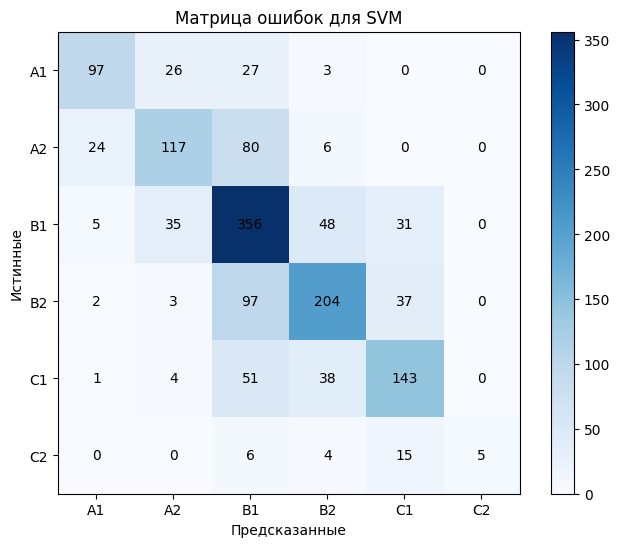

In [10]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

## Классификация. С1 и С2 вместе

In [11]:
y = df['textbook-assigned cefr level'].replace(6, 5).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    bert_embeddings, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [12]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test)

    results.append(result)

Обработка: Logistic Regression
Обработка: Decision Tree
Обработка: Random Forest
Обработка: CatBoost Classifier
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: LightGBM


In [13]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,4,SVM,0.641638,0.641638,0.640620,0.640118,0.458703
1,5,K-Nearest Neighbors,0.601365,0.601365,0.603151,0.601428,0.567918
2,3,CatBoost Classifier,0.601365,0.601365,0.600545,0.598999,0.516041
3,7,LightGBM,0.593174,0.593174,0.588997,0.591046,0.523549
4,2,Random Forest,0.551536,0.551536,0.539502,0.544734,0.587031
5,0,Logistic Regression,0.530375,0.530375,0.534694,0.530226,0.608874
6,6,Naive Bayes,0.473038,0.473038,0.482586,0.459248,0.756997
7,1,Decision Tree,0.361775,0.361775,0.351985,0.361369,0.972696


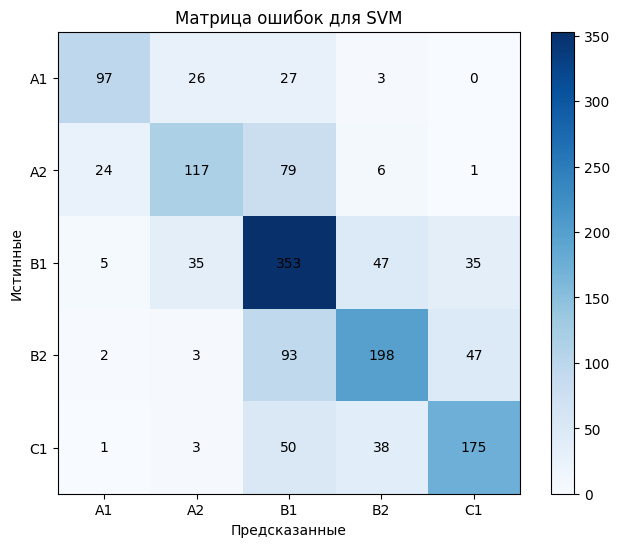

In [14]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

# Регрессия

In [15]:
models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    # ('Random Forest', RandomForestRegressor(random_state=42, max_depth=5)),
    # ('Gradient Boosting', GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5)),
    ('CatBoost Regressor', CatBoostRegressor(random_state=42, verbose=False)),
    ('SVM', SVR()),
    ('K-Nearest Neighbors', KNeighborsRegressor()),
    ('Naive Bayes', GaussianNB()),
    # ('XGBoost', XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_estimators=100)),
    ('LightGBM', LGBMRegressor(random_state=42, verbose=-1, n_estimators=100))
]

## Регрессия. С1 и С2 раздельно

In [16]:
y = df['textbook-assigned cefr level'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    bert_embeddings, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [17]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, round_type):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if round_type == 'math':
        y_pred = [round(i) for i in y_pred]
    elif round_type == 'ceil':
        y_pred = [math.ceil(i) for i in y_pred] 
    elif round_type == 'floor':
        y_pred = [math.floor(i) for i in y_pred] 

    y_pred = np.clip(y_pred, 1, 6).tolist()

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

### Математическое округление

In [18]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'math')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: LightGBM


In [19]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,3,SVM,0.542662,0.542662,0.451195,0.533905,0.520137
1,4,K-Nearest Neighbors,0.490785,0.490785,0.446606,0.485372,0.608874
2,2,CatBoost Regressor,0.483276,0.483276,0.408733,0.476484,0.585666
3,0,Linear Regression,0.467577,0.467577,0.422170,0.467822,0.614334
4,6,LightGBM,0.456655,0.456655,0.372745,0.447668,0.618430
5,5,Naive Bayes,0.445734,0.445734,0.431589,0.442385,0.843686
6,1,Decision Tree,0.372014,0.372014,0.321520,0.372308,0.950853


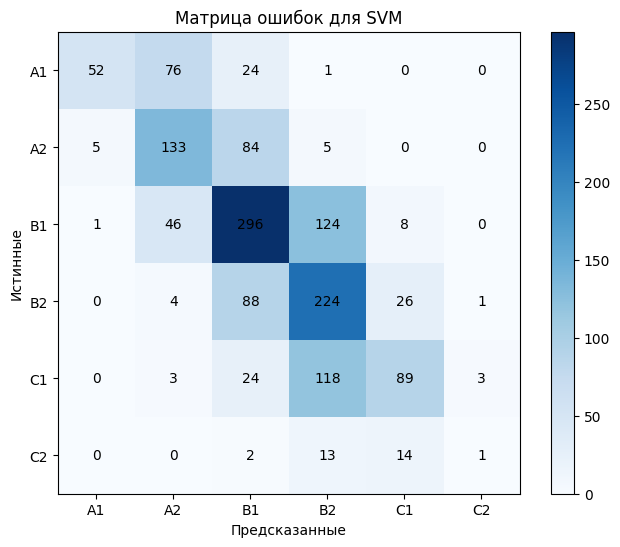

In [20]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вверх

In [21]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'ceil')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: LightGBM


In [22]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,5,Naive Bayes,0.445734,0.445734,0.431589,0.442385,0.843686
1,4,K-Nearest Neighbors,0.435495,0.435495,0.408241,0.416981,0.688737
2,3,SVM,0.395222,0.395222,0.335383,0.374733,0.713311
3,1,Decision Tree,0.372014,0.372014,0.321520,0.372308,0.950853
4,2,CatBoost Regressor,0.388396,0.388396,0.310740,0.360367,0.731058
5,0,Linear Regression,0.359727,0.359727,0.316887,0.356016,0.786348
6,6,LightGBM,0.374061,0.374061,0.285238,0.338480,0.742662


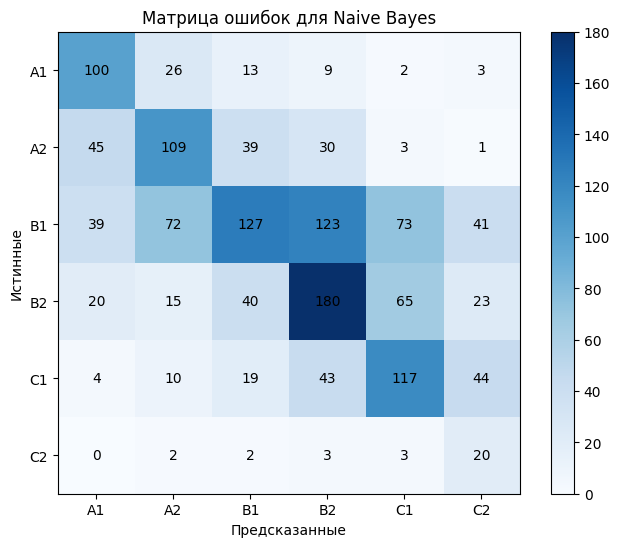

In [23]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вниз

In [24]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'floor')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: LightGBM


In [25]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,5,Naive Bayes,0.445734,0.445734,0.431589,0.442385,0.843686
1,4,K-Nearest Neighbors,0.450512,0.450512,0.369344,0.420807,0.681229
2,0,Linear Regression,0.425256,0.425256,0.375375,0.412396,0.711945
3,3,SVM,0.430034,0.430034,0.348073,0.402011,0.676451
4,6,LightGBM,0.423891,0.423891,0.331789,0.386038,0.698294
5,2,CatBoost Regressor,0.412969,0.412969,0.328518,0.379836,0.707850
6,1,Decision Tree,0.372014,0.372014,0.321520,0.372308,0.950853


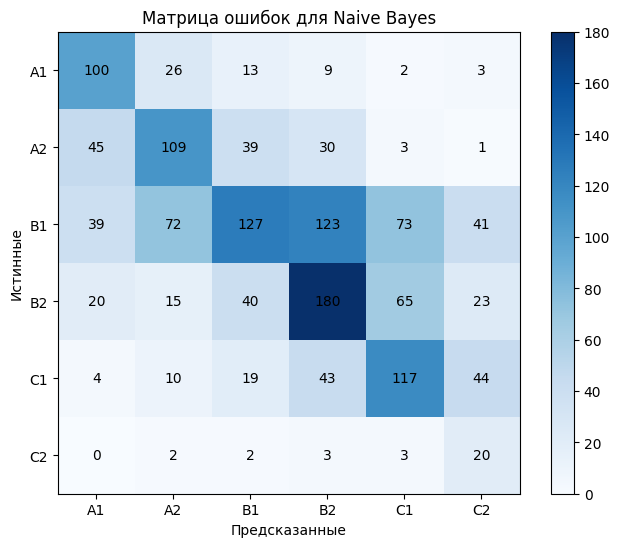

In [26]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

## Регрессия. С1 и С2 вместе

In [27]:
y = df['textbook-assigned cefr level'].replace(6, 5).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    bert_embeddings, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [28]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, round_type):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if round_type == 'math':
        y_pred = [round(i) for i in y_pred]
    elif round_type == 'ceil':
        y_pred = [math.ceil(i) for i in y_pred] 
    elif round_type == 'floor':
        y_pred = [math.floor(i) for i in y_pred] 

    y_pred = np.clip(y_pred, 1, 5).tolist()

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

### Математическое округление

In [29]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'math')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: LightGBM


In [30]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,3,SVM,0.546758,0.546758,0.529138,0.541233,0.507167
1,4,K-Nearest Neighbors,0.490102,0.490102,0.475720,0.484898,0.602730
2,2,CatBoost Regressor,0.483959,0.483959,0.468067,0.478692,0.574744
3,0,Linear Regression,0.474403,0.474403,0.473836,0.475246,0.593174
4,5,Naive Bayes,0.473038,0.473038,0.482586,0.459248,0.756997
5,6,LightGBM,0.468259,0.468259,0.445748,0.457716,0.595222
6,1,Decision Tree,0.380205,0.380205,0.379940,0.380313,0.900341


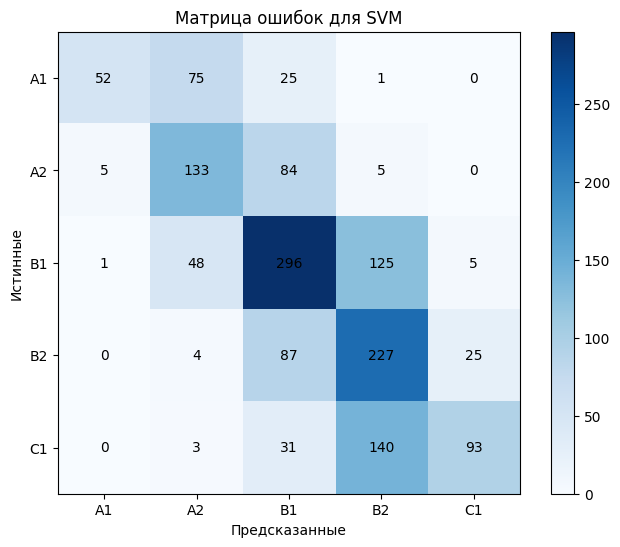

In [31]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вверх

In [32]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'ceil')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: LightGBM


In [33]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,5,Naive Bayes,0.473038,0.473038,0.482586,0.459248,0.756997
1,4,K-Nearest Neighbors,0.443686,0.443686,0.403520,0.426604,0.668942
2,3,SVM,0.425939,0.425939,0.380642,0.402934,0.668259
3,2,CatBoost Regressor,0.406143,0.406143,0.357447,0.380914,0.697611
4,1,Decision Tree,0.380205,0.380205,0.379940,0.380313,0.900341
5,0,Linear Regression,0.393857,0.393857,0.363392,0.377546,0.729010
6,6,LightGBM,0.400683,0.400683,0.337202,0.368246,0.707167


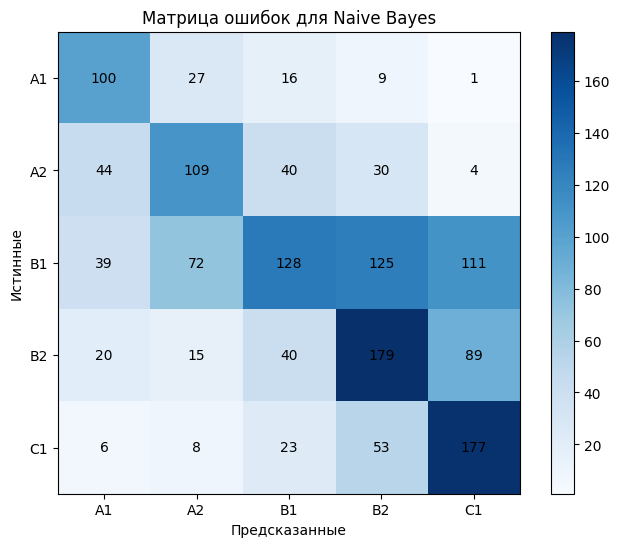

In [34]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вниз

In [35]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'floor')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: LightGBM


In [36]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,5,Naive Bayes,0.473038,0.473038,0.482586,0.459248,0.756997
1,4,K-Nearest Neighbors,0.452560,0.452560,0.429573,0.422131,0.672355
2,0,Linear Regression,0.419795,0.419795,0.412837,0.400241,0.702389
3,3,SVM,0.423891,0.423891,0.404512,0.391542,0.666894
4,1,Decision Tree,0.380205,0.380205,0.379940,0.380313,0.900341
5,2,CatBoost Regressor,0.412287,0.412287,0.379216,0.371206,0.701024
6,6,LightGBM,0.411604,0.411604,0.372914,0.365077,0.700341


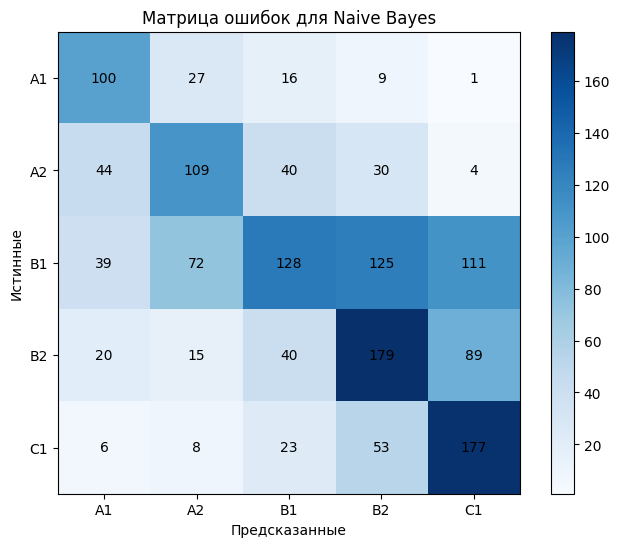

In [37]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()